# Footstep World-Frame Plot

`footstep_log.txt`의 **accumulated world frame** (`stance_world_`) 컬럼을 읽어
target footstep / VRP ref / CoM ref / current CoM 을
- **XY plane** (2D top-down)
- **Z vs tick**
으로 그립니다.

추가로 **leg IK target** (`q_leg_desired`) vs **measured joint** (`q_leg_meas`)을
플롯해, CoM을 깊게 내릴 때 IK가 풀리는지 / 정책이 따라가는지 확인합니다.

tocabi `commands.py` data.txt 로깅과 같은 의미:
`swing_target`, `ref_vrp_world`, `target_com_world`, `com_world`.

> world 컬럼이 포함된 로그가 필요합니다. `State_Footstep` 재빌드 후 러닝하세요.
> `q_leg_desired` / `q_leg_meas` 는 기존부터 로그에 포함되어 있습니다.

In [38]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fname = Path("footstep_log.txt")

base = [
    "tick", "walking_tick",
    "ref_zmp_x", "ref_zmp_y", "ref_zmp_z",
    "target_com_stance_x", "target_com_stance_y", "target_com_stance_z",
    "com_stance_x", "com_stance_y", "com_stance_z",
    "com_global_x", "com_global_y", "com_global_z",
    "lfoot_x", "lfoot_y", "lfoot_z",
    "rfoot_x", "rfoot_y", "rfoot_z",
    "target_com_global_x", "target_com_global_y", "target_com_global_z",
]
qdes = [f"q_leg_desired_{i}" for i in range(12)]
qmeas = [f"q_leg_meas_{i}" for i in range(12)]
world = [
    "phase_indicator",
    "swing_target_x", "swing_target_y", "swing_target_z",
    "ref_vrp_world_x", "ref_vrp_world_y", "ref_vrp_world_z",
    "target_com_world_x", "target_com_world_y", "target_com_world_z",
    "com_world_x", "com_world_y", "com_world_z",
    "stance_foot_x", "stance_foot_y", "stance_foot_z",
    "swing_foot_x", "swing_foot_y", "swing_foot_z",
]
cols = base + qdes + qmeas + world
n_cols = len(cols)  # 66

T = pd.read_csv(
    fname,
    sep="\t",
    skiprows=1,
    header=None,
    names=cols,
    usecols=range(n_cols),
    engine="python",
)
if T.iloc[-1].isna().any():
    T = T.iloc[:-1]

tick = T["tick"].to_numpy()
swing_tgt = T.filter(regex=r"^swing_target_").to_numpy()
vrp = T.filter(regex=r"^ref_vrp_world_").to_numpy()
com_des = T.filter(regex=r"^target_com_world_").to_numpy()
com_cur = T.filter(regex=r"^com_world_").to_numpy()
stance_f = T.filter(regex=r"^stance_foot_").to_numpy()
swing_f = T.filter(regex=r"^swing_foot_").to_numpy()

# Leg IK target (q_leg_desired) vs measured joint pos (q_leg_meas), SDK 0..11
# 0..5 left: hip_pitch, hip_roll, hip_yaw, knee, ankle_pitch, ankle_roll
# 6..11 right: same order
LEG_NAMES = [
    "L_hip_pitch", "L_hip_roll", "L_hip_yaw", "L_knee", "L_ankle_pitch", "L_ankle_roll",
    "R_hip_pitch", "R_hip_roll", "R_hip_yaw", "R_knee", "R_ankle_pitch", "R_ankle_roll",
]
q_ik = T.filter(regex=r"^q_leg_desired_").to_numpy()
q_meas = T.filter(regex=r"^q_leg_meas_").to_numpy()

print(f"rows={len(T)}, cols={T.shape[1]}")
print(f"CoM z drop: ref={com_des[:,2].min()-com_des[0,2]:+.3f} m, "
      f"meas={com_cur[:,2].min()-com_cur[0,2]:+.3f} m")
print(f"IK vs meas |err| mean={np.abs(q_meas - q_ik).mean():.4f} rad, "
      f"max={np.abs(q_meas - q_ik).max():.4f} rad")
T[["tick", "walking_tick", "phase_indicator",
   "swing_target_x", "swing_target_y", "swing_target_z",
   "ref_vrp_world_x", "target_com_world_x", "com_world_x"]].head()

rows=1637, cols=66
CoM z drop: ref=-0.013 m, meas=-0.029 m
IK vs meas |err| mean=0.0850 rad, max=0.8202 rad


,tick,walking_tick,phase_indicator,swing_target_x,swing_target_y,swing_target_z,ref_vrp_world_x,target_com_world_x,com_world_x
0,0,1,0.0,0.2782,-0.1185,0.0,-0.020346,0.045921,0.046490
1,1,2,0.0,0.2782,-0.1185,0.0,-0.016540,0.042872,0.046735
2,2,3,0.0,0.2782,-0.1185,0.0,-0.011239,0.038204,0.047074
3,3,4,0.0,0.2782,-0.1185,0.0,-0.005299,0.033432,0.047625
4,4,5,0.0,0.2782,-0.1185,0.0,0.000428,0.029297,0.048239


## XY plane (top-down)

world-frame X–Y. swing target는 step마다 거의 고정이라 scatter로도 표시.

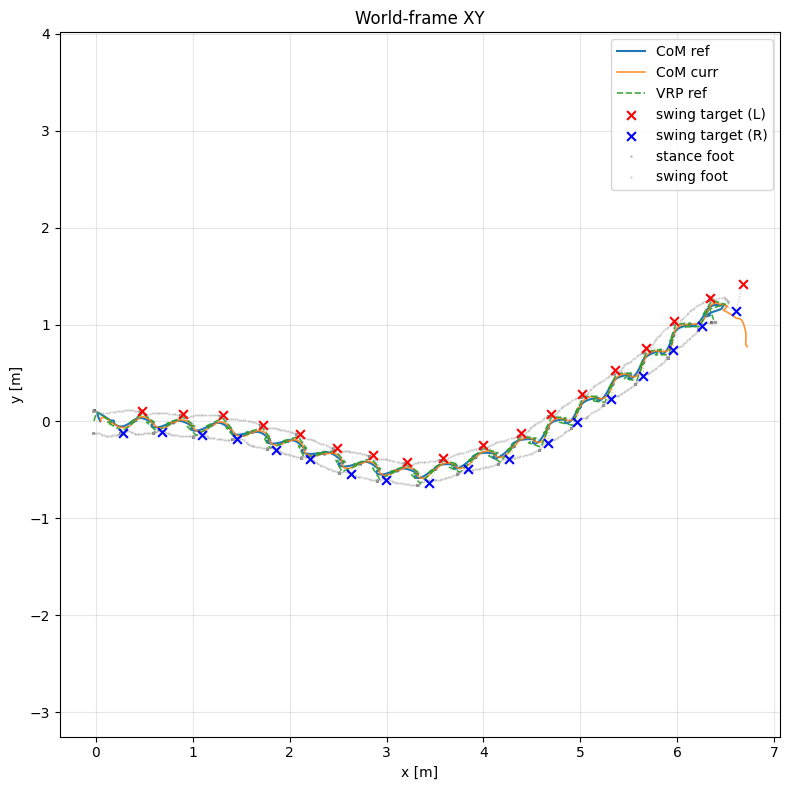

In [45]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(com_des[:, 0], com_des[:, 1], "-", lw=1.5, label="CoM ref", color="C0")
ax.plot(com_cur[:, 0], com_cur[:, 1], "-", lw=1.2, label="CoM curr", color="C1", alpha=0.85)
ax.plot(vrp[:, 0], vrp[:, 1], "--", lw=1.2, label="VRP ref", color="C2", alpha=0.9)

# unique swing targets (commanded landing) once per footstep
wt = T["walking_tick"].to_numpy()
step_idx = np.concatenate([[0], np.where(np.diff(wt) < 0)[0] + 1])

# phase_indicator: 0 = right foot swings, 1 = left foot swings
phase = T["phase_indicator"].to_numpy()[step_idx].astype(int)
left_idx = step_idx[phase == 1]
right_idx = step_idx[phase == 0]
ax.scatter(
    swing_tgt[left_idx, 0], swing_tgt[left_idx, 1],
    s=40, marker="x", color="red", label="swing target (L)", zorder=5,
)
ax.scatter(
    swing_tgt[right_idx, 0], swing_tgt[right_idx, 1],
    s=40, marker="x", color="blue", label="swing target (R)", zorder=5,
)
ax.plot(swing_tgt[:, 0], swing_tgt[:, 1], ":", lw=0.8, color="0.5", alpha=0.5)

ax.plot(stance_f[:, 0], stance_f[:, 1], ".", ms=1.5, color="0.4", alpha=0.4, label="stance foot")
ax.plot(swing_f[:, 0], swing_f[:, 1], ".", ms=1.5, color="0.6", alpha=0.35, label="swing foot")

ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("World-frame XY")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

## Z vs tick

높이 방향은 시간축으로 따로 플롯.

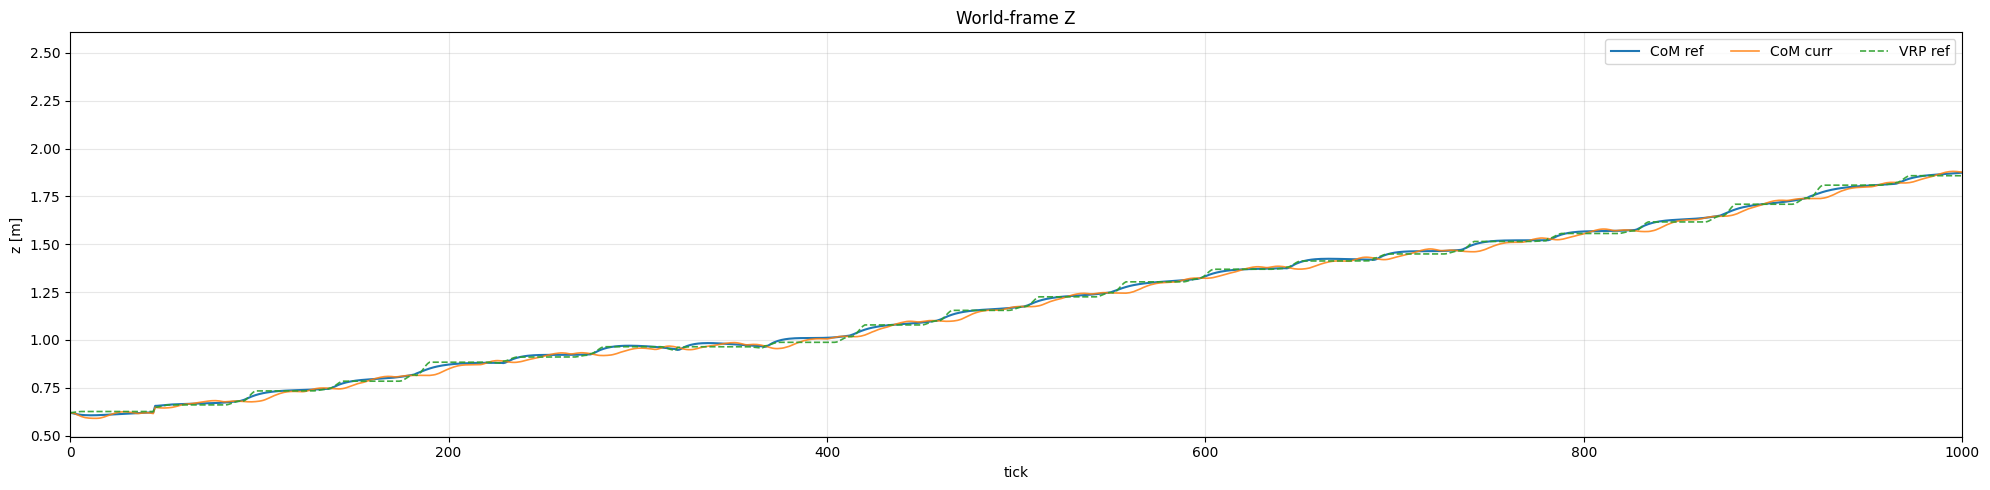

In [40]:
fig, ax = plt.subplots(figsize=(20, 5))

ax.plot(tick, com_des[:, 2], "-", lw=1.5, label="CoM ref", color="C0")
ax.plot(tick, com_cur[:, 2], "-", lw=1.2, label="CoM curr", color="C1", alpha=0.85)
ax.plot(tick, vrp[:, 2], "--", lw=1.2, label="VRP ref", color="C2", alpha=0.9)
# ax.plot(tick, swing_tgt[:, 2], ":", lw=1.2, label="swing target", color="C3")
# ax.plot(tick, stance_f[:, 2], "-", lw=0.8, color="0.4", alpha=0.5, label="stance foot")
# ax.plot(tick, swing_f[:, 2], "-", lw=0.8, color="0.6", alpha=0.45, label="swing foot")
ax.set_xlim(0, 1000)
ax.set_xlabel("tick")
ax.set_ylabel("z [m]")
ax.set_title("World-frame Z")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", ncol=3)
fig.tight_layout()
plt.show()

## XYZ overlay (optional)

각 축을 tick에 대해 나란히 비교.

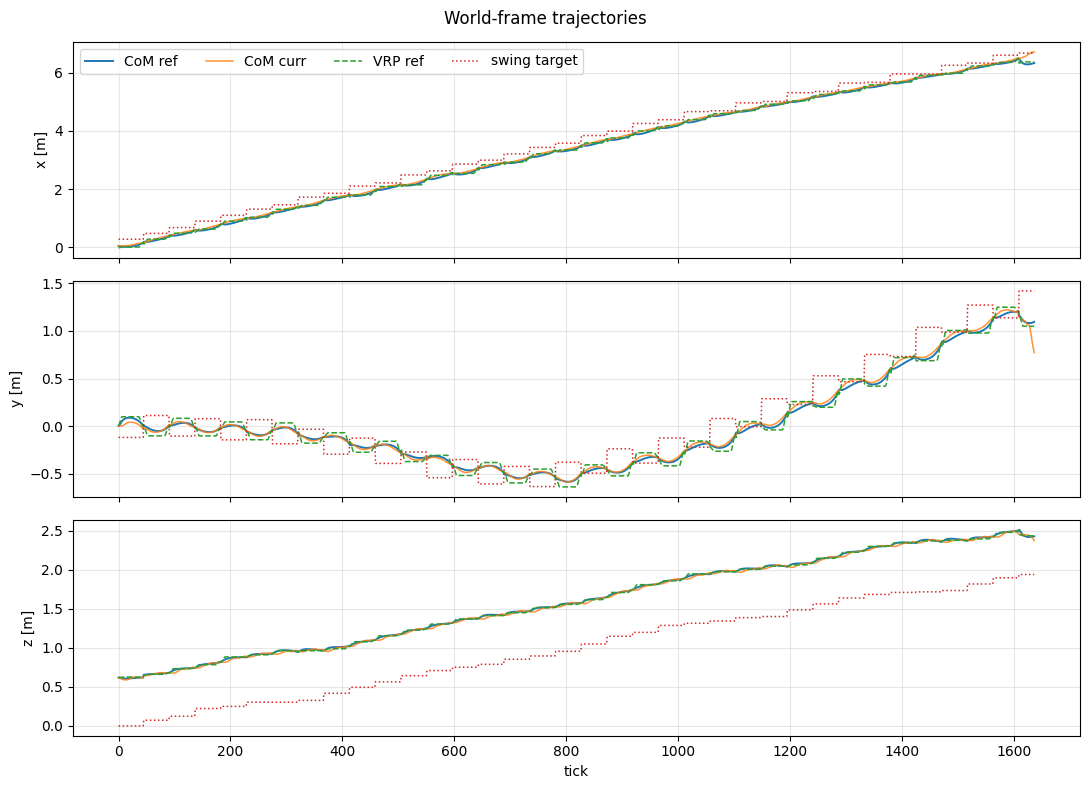

In [41]:
labels = ["x", "y", "z"]
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(tick, com_des[:, i], "-", lw=1.4, label="CoM ref", color="C0")
    ax.plot(tick, com_cur[:, i], "-", lw=1.1, label="CoM curr", color="C1", alpha=0.85)
    ax.plot(tick, vrp[:, i], "--", lw=1.1, label="VRP ref", color="C2")
    ax.plot(tick, swing_tgt[:, i], ":", lw=1.1, label="swing target", color="C3")
    ax.set_ylabel(f"{labels[i]} [m]")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc="best", ncol=4)
axes[-1].set_xlabel("tick")
fig.suptitle("World-frame trajectories")
fig.tight_layout()
plt.show()

## Crouch joints + CoM z

앉기에서 크게 움직이는 **hip_pitch / knee**만 모아보고, 같은 tick의 CoM z와 비교합니다.  
- IK target이 깊게 앉는 쪽으로 움직이는데 meas가 안 따라가면 → 정책 tracking 한계  
- IK target 자체가 거의 안 바뀌면 → IK/명령 경로 문제

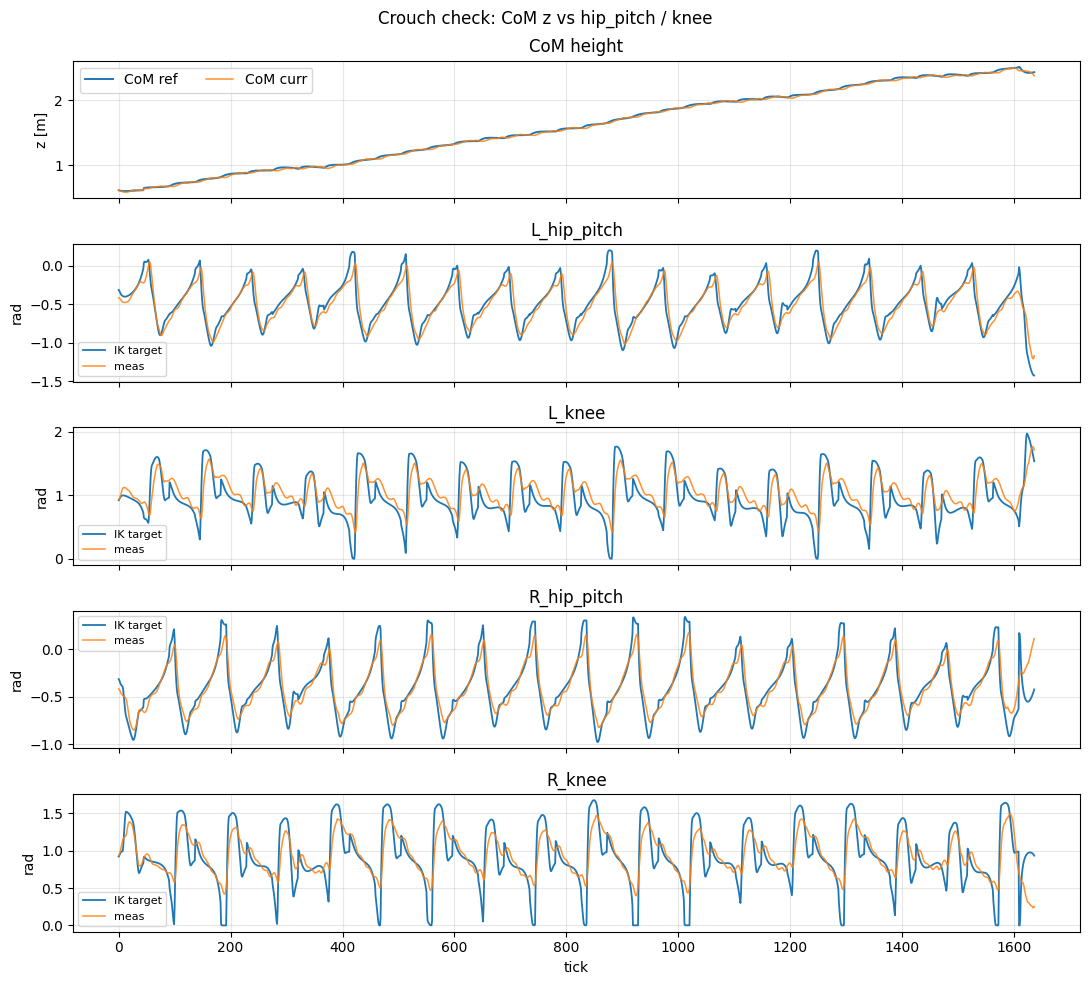

deepest CoM ref at tick=11: ref_z=0.606, curr_z=0.591
  L_hip_pitch     IK=-0.401  meas=-0.477  err=-0.075 rad
  L_knee          IK=+0.993  meas=+1.121  err=+0.128 rad
  R_hip_pitch     IK=-0.611  meas=-0.502  err=+0.109 rad
  R_knee          IK=+1.404  meas=+1.184  err=-0.220 rad


In [42]:
crouch_ids = [0, 3, 6, 9]  # L/R hip_pitch, L/R knee

fig, axes = plt.subplots(len(crouch_ids) + 1, 1, figsize=(11, 10), sharex=True)

ax = axes[0]
ax.plot(tick, com_des[:, 2], "-", lw=1.4, label="CoM ref", color="C0")
ax.plot(tick, com_cur[:, 2], "-", lw=1.1, label="CoM curr", color="C1", alpha=0.85)
ax.set_ylabel("z [m]")
ax.set_title("CoM height")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", ncol=2)

for ax, j in zip(axes[1:], crouch_ids):
    ax.plot(tick, q_ik[:, j], "-", lw=1.3, label="IK target", color="C0")
    ax.plot(tick, q_meas[:, j], "-", lw=1.1, label="meas", color="C1", alpha=0.85)
    ax.set_ylabel("rad")
    ax.set_title(LEG_NAMES[j])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

axes[-1].set_xlabel("tick")
fig.suptitle("Crouch check: CoM z vs hip_pitch / knee")
fig.tight_layout()
plt.show()

i_deep = int(np.argmin(com_des[:, 2]))
print(f"deepest CoM ref at tick={int(tick[i_deep])}: "
      f"ref_z={com_des[i_deep,2]:.3f}, curr_z={com_cur[i_deep,2]:.3f}")
for j in crouch_ids:
    print(f"  {LEG_NAMES[j]:14s}  IK={q_ik[i_deep,j]:+.3f}  meas={q_meas[i_deep,j]:+.3f}  "
          f"err={q_meas[i_deep,j]-q_ik[i_deep,j]:+.3f} rad")

## Joint tracking error (|meas − IK|)

전체 관절 tracking error. CoM이 깊게 내려갈수록 error가 커지면 OOD tracking 실패 신호입니다.

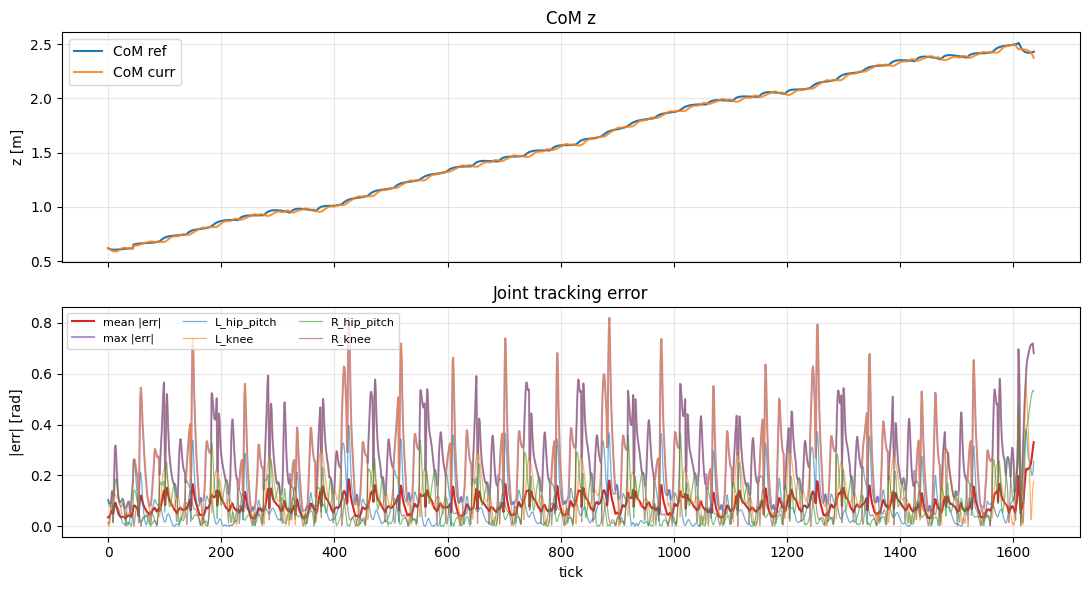

In [43]:
err = np.abs(q_meas - q_ik)
crouch_ids = [0, 3, 6, 9]  # L/R hip_pitch, L/R knee

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(tick, com_des[:, 2], label="CoM ref", color="C0")
axes[0].plot(tick, com_cur[:, 2], label="CoM curr", color="C1", alpha=0.85)
axes[0].set_ylabel("z [m]")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)
axes[0].set_title("CoM z")

axes[1].plot(tick, err.mean(axis=1), label="mean |err|", color="C3")
axes[1].plot(tick, err.max(axis=1), label="max |err|", color="C4", alpha=0.7)
for j, c in zip(crouch_ids, ["C0", "C1", "C2", "C5"]):
    axes[1].plot(tick, err[:, j], lw=0.9, alpha=0.6, label=LEG_NAMES[j], color=c)
axes[1].set_ylabel("|err| [rad]")
axes[1].set_xlabel("tick")
axes[1].legend(loc="best", ncol=3, fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_title("Joint tracking error")

fig.tight_layout()
plt.show()